# Projektaufgabe: SBL: bidirektionale Planung mit Lazy Collision Checking

**Vorlesung:** Innovative Konzepte zur Programmierung von Industrierobotern  
**Dozent:** Prof. Dr.-Ing. Björn Hein  
**Gruppe:** <br>
    Christian Mentenich (ugqua) <br>
    Gabrielle Mentenich (udwse) <br>
    Michael Poncelet (urphy) <br>
**Aufgabe:** SBL: bidirektionale Planung mit Lazy Collision Checking  
**Abgabedatum:** 30.07.2026  
**Vortragsdatum:** 31.07.2026

## 1. Abstract

Fassen Sie kurz Problem, Ansatz, wichtigste Ergebnisse und offene Punkte zusammen.

## 2. Objective

Beschreiben Sie die konkrete Aufgabenstellung, eigene Teilziele und experimentelle Fragestellungen.

Michael

Christian
What is the meaning of Lazy Collision Checking?
Lazy Collision Checking is a method used in pathfinding where collsion checks are delayed or only performed when necessary. Lazy Collision Checking tries to minimize collision checks
and tries to reuse information gathered by queries. This reduces computation time and improves the efficiency of pathfinding.

Why are local connection tests often the most expensive part of path planning?

Local connectivity checks are expensive because they must validate continuous paths instead of single points.
The computer must break down every single connection into tiny intermediate steps and run collision checks for each one. 
Because this process is repeated millions of times even if it is not guaranteed that the path will be used, it consumes the majority of the total computation time. Also if a test is collision-free it is the most expensive because the most possible number of collision checks needs to be made.

#### Single-query planner
A single query planner uses single or bidirectional search trees that grow through the free space until a 
path from start to goal is found. They work great for dynamic or unknown environments, as they can adapt to 
changes in the environment without requiring a complete map of the space (like multi-query algorithms). In comparison to multi-query algorithms, they are slower per query since they build and search the paths simoultaneously.

#### Goal of this project
The goal is to implement, evaluate, and document an SBL-inspired robot motion planner (Single-query, Bidirectional, Lazy Collision Checking). Unlike multi-query approaches (such as PRM), this planner specifically optimizes for a single start-to-goal problem.

#### Core concepts of the planner
1. Bidirectional Tree Growth: Two trees grow simultaneously, one from the start configuration ($T_{start}$) and one from the goal configuration ($T_{goal}$).
2. Lazy Evaluation: Collision checking of edges is delayed as long as possible. It is only executed once a potential connection (candidate path) between both trees has been found.
3. Adaptive Local Collision Checking: An adaptive midpoint check is used to validate edges. This iteratively checks the midpoint of a segment until the segment length is smaller than $\epsilon$ (epsilon). The test aborts immediately upon detecting the first collision (Early Exit).

## 3. Initial Code and Used Modules

Dokumentieren Sie verwendete Module, erweiterte Klassen/Funktionen, neue Module und den Startpunkt der eigenen Lösung.

In [13]:
import sys
from pathlib import Path
from shapely.geometry import Polygon
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from matplotlib.collections import LineCollection

REPO_ROOT = Path.cwd().parent
sys.path.insert(0, str(REPO_ROOT))

REPO_ROOT

PosixPath('/home/mp/Documents/KIT/ikp-sbl')

Similar tree growth to RRT algorithm, but RRT checks for line (edge) collision before adding them, while SBL only checks for valid nodes at first (lazy collision checking).

## 4. Concept und Algorithm

Beschreiben Sie den Algorithmus fachlich. Nutzen Sie Skizzen, Pseudocode, Tabellen oder kurze Formeln, wenn sie helfen.

## 5. Implementation

Most important implementation decisions and necessary modules.

In [14]:
# Import the necessary modules for the SBL implementation

#from modules import search_tree
#from modules.search_tree import BidirectionalSBL
#from lecture_examples.IPEnvironment import CollisionChecker
from shapely.geometry import Polygon
from datetime import datetime

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from matplotlib.collections import LineCollection


In [15]:
# Eigene Module importieren
# from modules.search_tree import BidirectionalSBL
from planners.SBL import BidirectionalSBL
from lecture_examples.IPEnvironment import CollisionChecker
from modules import draw
from modules import sbl_checkpoints as checkpoints
from modules import randomScene

In [16]:
# Set global variables for better overview and easier adjustments

START = [1.0, 1.0] # Start position
GOAL = [20.0, 20.0] # Goal position
SCENE_LIMITS = np.array([[0,22],[0,22]])
CHECKPOINT_PATH = REPO_ROOT / "checkpoints" / "sbl_checkpoints.json"
GIF_PATH = REPO_ROOT / "gifs"

In [17]:
benchmark = randomScene.create_random_benchmark(SCENE_LIMITS)
#scene = {"wall": Polygon([(5, 5), (5, 15), (15, 15), (15, 5)])}
planner = BidirectionalSBL(benchmark.collisionChecker)

#T_start, T_goal, path = planner.grow_trees(START, GOAL)
#print(len(T_start.nodes()), len(T_goal.nodes()), path)

KeyboardInterrupt: 

Collision found between Node [5.7165653  6.45794345] at start tree - Node [6.51493748 7.06010776] at start tree
Collision found between Node [17.3033607  15.29840907] at goal tree - Node [16.33551764 15.04685428] at goal tree


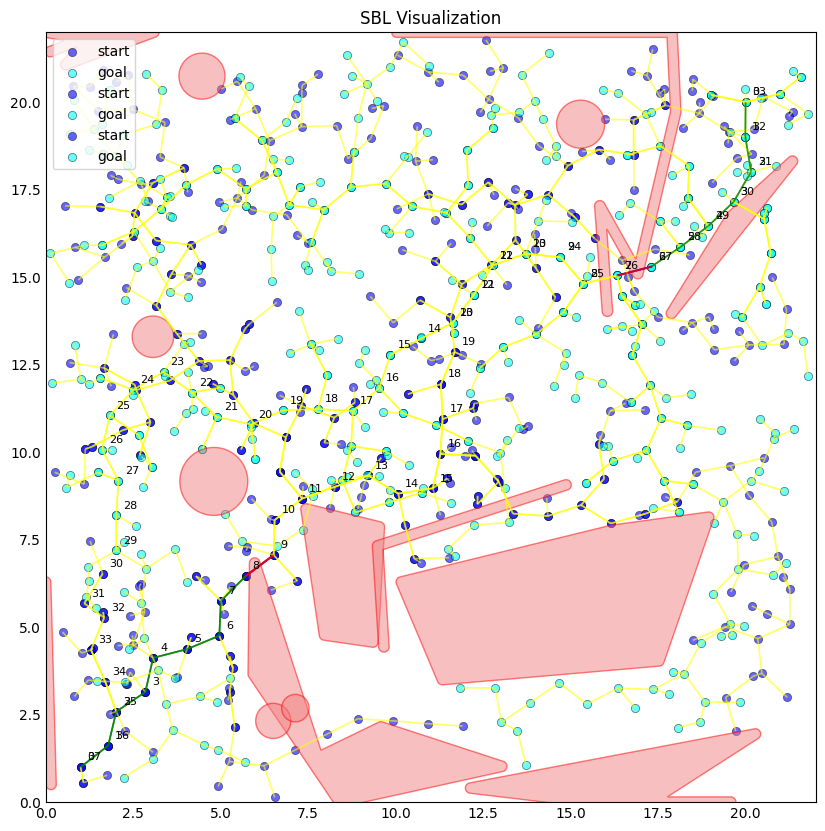

In [ ]:
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(1, 1, 1)
T_start, T_goal, path = planner.plan_path(START, GOAL, ax, checkpoint_path=str(CHECKPOINT_PATH))

draw.draw_obstacles(ax, benchmark.collisionChecker.scene)

ax.set_title("SBL Visualization")
ax.set_xlim(*SCENE_LIMITS[0])
ax.set_ylim(*SCENE_LIMITS[1])
ax.tick_params(axis="both", which="both", length=0)
ax.set_aspect("equal", adjustable="box")
ax.legend(loc="upper left")

plt.show()

In [ ]:
checkpoints.animate(CHECKPOINT_PATH,benchmark.collisionChecker.scene,SCENE_LIMITS)

In [ ]:
gif_filename=GIF_PATH / f"sbl-plan_{datetime.now().strftime("%Y-%m-%d_%H-%M-%S")}.gif"
checkpoints.export_gif(CHECKPOINT_PATH,gif_filename,benchmark.collisionChecker.scene,SCENE_LIMITS)

PosixPath('/home/mp/Documents/KIT/ikp-sbl/gifs/sbl-plan_2026-07-13_21-25-44.gif')

## 6. Validation with examples

Zeigen Sie an kleinen, nachvollziehbaren Fällen, dass die zentralen Bausteine korrekt funktionieren.

In [ ]:
# Kleine Tests oder Plausibilitaetschecks ausfuehren.
pass

## 7. Experiments and Benchmarks

Beschreiben Sie Testumgebungen, Parameter, Metriken und Anzahl der Wiederholungen.

In [ ]:
# Benchmark-Konfigurationen definieren.
benchmarks = []
configs = []

## 8. Visualization and Animations

Zeigen Sie Suchraum, Roadmap/Baum, Pfad, Kollisionen, Statistiken oder Animationen.

In [ ]:
# Visualisierungen erzeugen.
pass

## 9. Results

Stellen Sie Ergebnisse in Tabellen und Diagrammen dar und erklären Sie beobachtete Effekte.

In [ ]:
# Ergebnisse als DataFrame/Tabelle/Plot darstellen.
pass

## 10. Discussion

Diskutieren Sie, was funktioniert hat, wo Grenzen liegen, welche Parameter wichtig sind und wie belastbar die Ergebnisse sind.

## 11. Conclusion

Fassen Sie die wichtigsten Erkenntnisse knapp zusammen.

## 12. Use of AI Tools

Dokumentieren Sie, wofür KI verwendet wurde, welche Vorschläge übernommen oder verworfen wurden und wie die Korrektheit geprüft wurde.

* General coding and refactoring assistance (writing classes and functions)
* Theoretical explanation of concepts

## 13. Presentation Notes

Notieren Sie die Kernaussagen für die Präsentation: Problem, Ansatz, wichtigste Visualisierung, wichtigste Ergebnisse und wichtigste Erkenntnis.